In [1]:
import os

print(os.getcwd())

/home/rauf/Repos/ml-class-project/notebooks


In [2]:
"../data/external/corpus_inventory.csv"

'../data/external/corpus_inventory.csv'

## Environment Verification

Before loading the dataset, the notebook verifies the current working directory and confirms that the corpus inventory file is available at the expected location.

In [3]:
import os

print(os.getcwd())
print(os.path.exists("../data/external/corpus_inventory.csv"))

/home/rauf/Repos/ml-class-project/notebooks
True


### Observation

The notebook is running from the project notebooks directory, and the corpus inventory file was successfully located. This confirms that the dataset is accessible for subsequent analysis.

## Loading the Corpus Inventory

The corpus inventory file is loaded into a pandas DataFrame. This inventory contains metadata for each page image, including file size, image dimensions, and text length information.

In [4]:
import pandas as pd

df = pd.read_csv("../data/external/corpus_inventory.csv")

df.head()

,book_id,page_id,image_path,text_path,image_bytes,text_bytes,image_width,image_height
0,2015.328360.Andhra-Mahaniyulu,page_0002,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,176344,40,1500,2155
1,2015.328360.Andhra-Mahaniyulu,page_0004,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,367361,2191,1500,2155
2,2015.328360.Andhra-Mahaniyulu,page_0005,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,486256,2932,1500,2155
3,2015.328360.Andhra-Mahaniyulu,page_0006,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,490581,2830,1500,2155
4,2015.328360.Andhra-Mahaniyulu,page_0007,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,data/raw/telugu-ocr/2015.328360.Andhra-Mahaniy...,494685,2846,1500,2155


### Observation

The first few rows confirm that the dataset was loaded successfully. Each record corresponds to a page in the corpus and includes identifiers, file paths, image dimensions, image sizes, and text-length metadata that will be used for corpus characterization.

# Corpus Overview

This notebook characterizes the Telugu OCR corpus by examining page dimensions,
text lengths, and image file sizes. The objective is to summarize the corpus and
understand its characteristics before developing and evaluating OCR models.

In [5]:
print("Total pages:", len(df))
print("Total books:", df["book_id"].nunique())

Total pages: 415
Total books: 5


## Interpretation

The corpus consists of 415 pages distributed across 5 books. This provides a
moderately sized dataset for evaluating OCR performance on Telugu-language
documents. Understanding the corpus characteristics is important for assessing
data quality and interpreting OCR model performance in later project phases.

In [6]:
df.describe()

,image_bytes,text_bytes,image_width,image_height
count,415.000000,415.000000,415.0,415.000000
mean,478787.860241,3145.450602,1500.0,2196.865060
std,83775.518814,1244.505517,0.0,99.031206
min,98413.000000,40.000000,1500.0,1815.000000
25%,434687.000000,2561.000000,1500.0,2121.000000
50%,489078.000000,2882.000000,1500.0,2261.000000
75%,539117.000000,3374.000000,1500.0,2284.000000
max,622673.000000,7873.000000,1500.0,2284.000000


## Summary Statistics Interpretation

The corpus contains 415 page images. Image widths are uniform at 1500 pixels, indicating a consistent scanning process across the collection. Image heights vary modestly, with a median height of 2261 pixels, suggesting minor differences in page dimensions or cropping.

The median image file size is approximately 489,078 bytes, while file sizes range from about 98,413 bytes to 622,673 bytes. This variation may reflect differences in page content density, image complexity, or scan quality.

Text lengths also vary substantially across pages. The median text length is 2,882 bytes, with values ranging from 40 bytes to 7,873 bytes. This suggests that some pages contain very little text (e.g., title pages or blank pages), while others contain significantly more textual content.

## Image File Size Distribution

The distribution of image file sizes is examined to understand the variability in scanned page quality and image complexity across the corpus. File size can serve as a proxy measure for scan density, page content, and image detail.

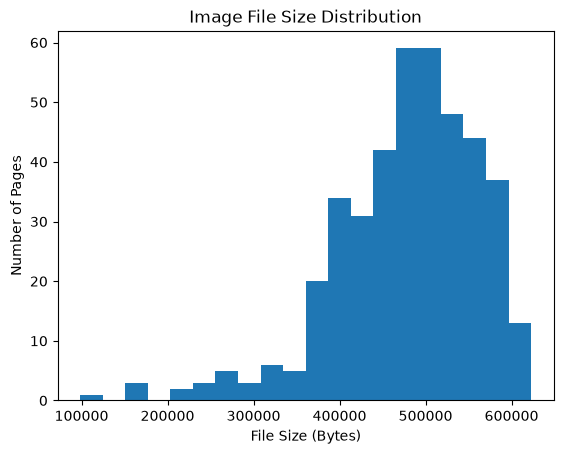

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["image_bytes"], bins=20)
plt.title("Image File Size Distribution")
plt.xlabel("File Size (Bytes)")
plt.ylabel("Number of Pages")
plt.show()

### Interpretation

The image file sizes are concentrated primarily between 450,000 and 600,000 bytes, with a peak around 500,000 bytes. This suggests that most pages were scanned using a relatively consistent process and exhibit similar image quality characteristics.

A small number of pages have substantially smaller file sizes, creating a left-tailed distribution. These pages may correspond to title pages, sparsely populated pages, or pages with lower image complexity. Overall, the distribution indicates that the corpus is relatively uniform in scan quality, which is beneficial for subsequent OCR experiments and performance evaluation.

## Interpretation

The corpus contains 415 pages distributed across 5 books. These headline
statistics provide a high-level overview of the dataset and establish the scope
of the corpus used in subsequent OCR experiments.

In [8]:
print("Total pages:", len(df))
print("Total books:", df["book_id"].nunique())

Total pages: 415
Total books: 5


The corpus contains 415 pages and 5 books. These values are used to generate
the JSON artifact. The values indicate there are 415 pages and 5 books...

## Summary Statistics

The following summary statistics provide an overview of the corpus metadata,
including image dimensions, image file sizes, and text lengths. These measures
help characterize the dataset and identify variability across the scanned pages.

In [9]:
df.describe()

,image_bytes,text_bytes,image_width,image_height
count,415.000000,415.000000,415.0,415.000000
mean,478787.860241,3145.450602,1500.0,2196.865060
std,83775.518814,1244.505517,0.0,99.031206
min,98413.000000,40.000000,1500.0,1815.000000
25%,434687.000000,2561.000000,1500.0,2121.000000
50%,489078.000000,2882.000000,1500.0,2261.000000
75%,539117.000000,3374.000000,1500.0,2284.000000
max,622673.000000,7873.000000,1500.0,2284.000000


## Interpretation

The corpus contains 415 page images with a consistent image width of 1500 pixels,
indicating a standardized scanning process. Image heights vary moderately, with a
median height of 2261 pixels, suggesting minor differences in page dimensions or
cropping.

The median image file size is approximately 489,078 bytes, while file sizes range
from about 98,413 bytes to 622,673 bytes. This variation may reflect differences
in page content, image complexity, and scan density across the corpus.

Text lengths also vary substantially among pages. The median text length is
2,882 bytes, with values ranging from 40 bytes to 7,873 bytes. This indicates
that some pages contain very little text (such as title pages or sparsely populated
pages), whereas others contain considerably more textual content. Understanding
this variability is important for interpreting OCR performance in later phases of
the project.

## Generating the Corpus Statistics Artifact

To support downstream project tasks and provide a reusable summary of the corpus,
the key descriptive statistics are exported to a JSON file. This artifact contains
the headline corpus metrics, including the number of books, number of pages,
image dimensions, text-length statistics, and file-size statistics.

In [10]:
# Estimate scan resolution assuming a 6-inch page width
df["dpi_estimate"] = df["image_width"] / 6.0

print(f"Estimated DPI: {df['dpi_estimate'].iloc[0]:.0f} (uniform across {len(df)} pages)")
print(f"All images: {df['image_width'].iloc[0]} px wide")

Estimated DPI: 250 (uniform across 415 pages)
All images: 1500 px wide


In [11]:
import json

stats = {
    "total_books": int(df["book_id"].nunique()),
    "total_pages": int(len(df)),
    "median_image_width_px": int(df["image_width"].median()),
    "median_image_height_px": int(df["image_height"].median()),
    "mean_text_length_chars": float(df["text_bytes"].mean()),
    "median_text_length_chars": float(df["text_bytes"].median()),
    "median_file_size_bytes": int(df["image_bytes"].median()),

    "dpi_estimate": float(df["dpi_estimate"].iloc[0]),
    "image_width_uniform": bool(df["image_width"].nunique() == 1)
}

with open("../data/external/corpus_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("corpus_stats.json created")

corpus_stats.json created


### Result

The file `corpus_stats.json` was successfully generated and stored in the
`data/external/` directory. This JSON artifact provides a compact machine-readable
summary of the corpus and can be reused by subsequent project phases, reports,
and evaluation workflows without requiring the statistics to be recomputed.

## Image File Size Distribution

The distribution of image file sizes is examined to assess the variability in
the scanned pages. File size serves as a useful proxy for image complexity,
page content density, and scan quality across the corpus.

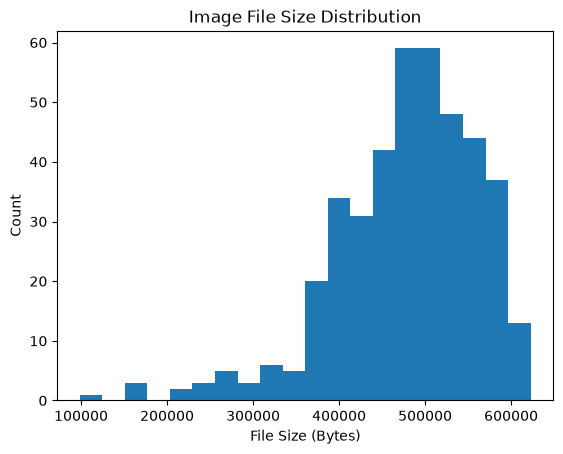

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["image_bytes"], bins=20)
plt.title("Image File Size Distribution")
plt.xlabel("File Size (Bytes)")
plt.ylabel("Count")
plt.show()

### Interpretation

The image file sizes are concentrated primarily between 450,000 and 600,000
bytes, with a peak around 500,000 bytes. This suggests that most pages were
scanned using a relatively consistent process and exhibit similar image quality
characteristics.

A smaller number of pages have substantially lower file sizes, creating a
left-tailed distribution. These pages may correspond to title pages, sparsely
populated pages, pages containing less visual information, or scans with reduced
image complexity.

Overall, the distribution indicates that the corpus is relatively uniform in
terms of scan quality and image characteristics. This consistency is beneficial
for OCR experiments because it reduces variability introduced by differences in
image resolution and scanning conditions, allowing model performance to be
evaluated more reliably.

## Text Length Distribution

The distribution of text lengths is examined to understand the variability in
the amount of textual content present on each page. Differences in text length
may reflect variations in page structure, document formatting, and content
density across the corpus.

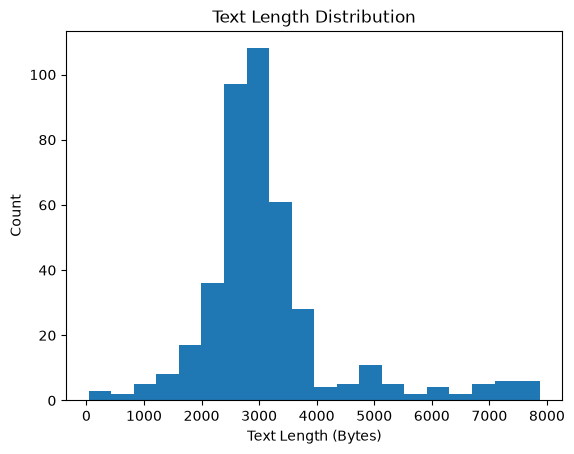

In [13]:
plt.hist(df["text_bytes"], bins=20)
plt.title("Text Length Distribution")
plt.xlabel("Text Length (Bytes)")
plt.ylabel("Count")
plt.show()

## Interpretation

The text-length distribution is concentrated primarily between 2,000 and 3,500
bytes, with a peak around 2,800–3,000 bytes. This indicates that most pages
contain a similar amount of textual content and are relatively consistent in
their content density.

The distribution exhibits a noticeable right skew, with a small number of pages
containing substantially more text than the majority of the corpus. These pages
may represent sections with dense narrative content, while pages with very low
text lengths may correspond to title pages, chapter headings, illustrations, or
other sparsely populated pages.

The observed variability in text length is important for OCR evaluation because
pages with very little text may produce unstable accuracy estimates, whereas
text-dense pages provide more opportunities to assess character- and word-level
recognition performance.

## Image Dimension Distribution

The distribution of image dimensions is examined by calculating the total number
of pixels in each page image (width × height). This metric provides a summary
of page size and helps identify variation in image dimensions across the corpus.

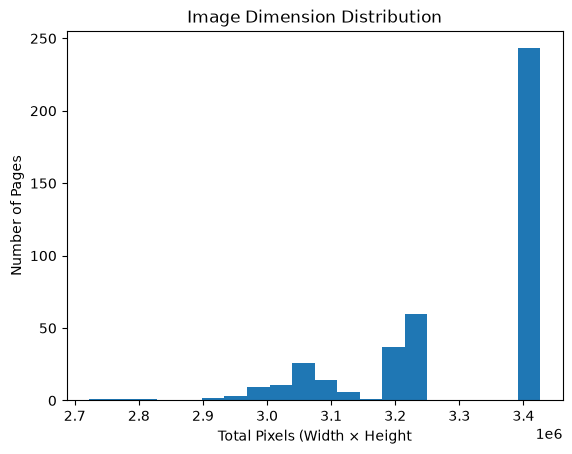

In [14]:
page_pixels = df["image_width"] * df["image_height"]

plt.hist(page_pixels, bins=20)
plt.title("Image Dimension Distribution")
plt.xlabel("Total Pixels (Width × Height")
plt.ylabel("Number of Pages")
plt.show()

## Interpretation

The image dimension distribution shows that most pages are concentrated around
3.4 million total pixels, indicating a high degree of consistency in image size
throughout the corpus. This observation is expected because all page images have
a uniform width of 1500 pixels, while page heights vary only within a limited
range.

A smaller number of pages exhibit lower total pixel counts, suggesting reduced
page heights or differences in cropping. These pages form secondary clusters in
the distribution but represent a relatively small portion of the dataset.

Overall, the distribution indicates that the corpus was produced using a largely
standardized scanning process. Consistent image dimensions are beneficial for OCR
experiments because they reduce variability introduced by differences in page
size and image resolution, allowing model performance to be evaluated under more
uniform conditions.

## Estimated Scan Resolution (DPI)

The corpus inventory does not include EXIF metadata or explicit DPI information.
Following the project specification, an approximate scan resolution is estimated
using the image width under the assumption that each scanned page is
approximately 6 inches wide.

In [15]:
df["dpi_estimate"] = df["image_width"] / 6.0

print(f"Estimated DPI: {df['dpi_estimate'].iloc[0]:.0f} (uniform across {len(df)} pages)")
print(f"All images: {df['image_width'].iloc[0]} px wide")

Estimated DPI: 250 (uniform across 415 pages)
All images: 1500 px wide


### Interpretation

The scan resolution was estimated by assuming a page width of approximately
6 inches. Using the observed image width of 1500 pixels results in an estimated
resolution of approximately 250 DPI for every page in the corpus.

All images in the analyzed subset have an identical width of 1500 pixels,
indicating that the corpus was scanned using a highly consistent horizontal
resolution. This uniformity reduces variability caused by differing scan
resolutions and provides a stable input for OCR experiments.

Although the image width is constant, page heights vary between approximately
1815 and 2284 pixels. Without EXIF metadata or physical page dimensions, it is
not possible to determine whether this variation reflects differences in page
sizes or differences in scanner cropping. Consequently, the estimated DPI should
be regarded as an approximation based on the assumed page width.